# Chapter 01: Algebraic Structures and Mathematics before Numbers

**Source span:** PDF pages 4-19 of *Mathematical Foundations of Geometric Deep Learning*.

**Chapter goal:** turn the chapter's pre-numerical language into executable objects: finite sets, maps, products, groups, actions, vector spaces, tensor spaces, and checks for invariance and equivariance.

This notebook treats algebraic structure as a design constraint. A set tells us which objects are in scope. A map tells us how data moves. A group tells us which transformations can be composed and undone. A group action tells us how transformations move the domain of a signal. Invariance and equivariance then become testable statements about functions, not slogans.

The examples are intentionally finite whenever possible. Finite models let us inspect every element, every arrow, every table entry, and every residual before the same ideas are scaled to images, graphs, manifolds, or neural-network tensors.


## Translation guide and computational dictionary

| Chapter idea | Notebook representation | What we check |
| --- | --- | --- |
| Set, subset, power set | Python `set`/`frozenset`, Hasse diagram | duplicate removal, subset edges, `|P(A)| = 2^|A|` |
| Cartesian product | list of ordered tuples | product cardinality and coordinate order |
| Map | dictionary from domain elements to codomain elements | injective, surjective, bijective classification |
| Function composition | composed dictionaries or NumPy functions | associativity of composition on finite examples |
| Finite group | element list plus binary operation | closure, identity, inverses, associativity |
| Cayley graph | NetworkX directed graph | every generator sends group elements to group elements |
| Group action | `action(g, x)` on vertices or signals | identity and compatibility axioms |
| Invariance | scalar function constant on an orbit | zero orbit-pooling residual |
| Equivariance | output transforms with the input | zero residual for circular convolution |
| Tensor notation | NumPy arrays and `einsum` strings | shapes and contractions match explicit computations |

**Library routing.** Matplotlib is used for durable labeled 2D diagrams. NetworkX is used because Cayley graphs and subset lattices are graph objects. Plotly is used for an inspectable standalone HTML Cayley graph. NumPy and pandas make the finite algebra executable; SymPy is used for exact symbolic/vector-space identities where exactness matters.

**Reader audit loop.** After each section, ask three questions. What is the underlying set? What operation or map is being applied? Which property survives after the allowed transformation? This loop is intentionally repetitive because the same pattern reappears later in the book with manifolds, spectra, graphs, and neural layers. The finite examples here are not toy replacements for the theory; they are small witnesses that make the axioms falsifiable. If an operation fails closure, if a map misses a codomain element, or if a residual changes after a group action, the structure being claimed is not the structure actually implemented.

## Visual storyboard

1. Sets and products: compare membership regions, a power-set lattice, ordered-pair grids, and finite map arrows.
2. Groups: compute Cayley tables, draw Cayley graphs, and separate abelian `C4` behavior from non-abelian `D3` behavior.
3. Actions: let `C4` move vertices, signals, and a small image, then measure invariant and equivariant residuals.
4. Tensors: route indexed notation into `np.einsum` and verify every contraction against a direct array computation.


In [1]:
from pathlib import Path
import os
import sys

cwd = Path.cwd().resolve()
root_candidates = [cwd, *cwd.parents]
root_candidates.append(cwd / "Mathematical-Foundations-of-Geometric-Deep-Learning")
for candidate in root_candidates:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find the MFGDL book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-01"
for folder in ["figures", "html", "tables", "checks"]:
    (ARTIFACT_ROOT / folder).mkdir(parents=True, exist_ok=True)

EXPECTED_ARTIFACTS = [
    "figures/set_power_cartesian_map_panel.png",
    "figures/c4_cayley_graph_and_table.png",
    "figures/d3_noncommutative_cayley_graph.png",
    "figures/action_orbit_invariance_equivariance.png",
    "figures/tensor_einsum_index_flow.png",
    "html/d3_cayley_graph_generators.html",
    "tables/map_classification.csv",
    "tables/c4_cayley_table.csv",
    "tables/d3_cayley_table.csv",
    "tables/c4_equivariance_lab.csv",
    "checks/algebraic_structure_invariants.json",
    "checks/final-sanity.json",
]

# Remove stale generated files in this assigned artifact subtree only.
expected = set(EXPECTED_ARTIFACTS)
removed_stale = []
for path in sorted(ARTIFACT_ROOT.rglob("*")):
    if path.is_file():
        rel = path.relative_to(ARTIFACT_ROOT).as_posix()
        if rel not in expected:
            path.unlink()
            removed_stale.append(rel)

print(f"Resolved book root: {BOOK_ROOT.name}")
print(f"Chapter artifact root = {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")
print(f"Removed stale chapter-01 artifacts: {removed_stale or 'none'}")

def display_path(path):
    return Path(os.path.relpath(Path(path), start=Path.cwd()))



Resolved book root: Mathematical-Foundations-of-Geometric-Deep-Learning
Chapter artifact root = artifacts\chapter-01
Removed stale chapter-01 artifacts: none


In [2]:
import itertools
import json
import math
from collections import Counter

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import Markdown, display

from utils.artifacts import display_artifact, save_matplotlib, save_plotly_html
from utils.notebook_checks import assert_chapter_artifacts, assert_nonblank_image

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
})

rng = np.random.default_rng(17)
checks = {"source_span_pdf_pages": "4-19"}


## 1. Sets, Power Sets, Cartesian Products, and Maps

A set forgets order and repeated entries. That sounds minor until it becomes a modeling choice: graph nodes form a set, while a node neighborhood in a message-passing layer is often a multiset because repeated labels can matter. The diagrams below keep four related constructions visible at once.

Inspect the power-set lattice from bottom to top: moving upward adds one element. Inspect the Cartesian grid row by row: the ordered pair `(a, b)` is not the same datum as `(b, a)`. Inspect the map arrows: a map can be one-to-one, onto, both, or neither, and those labels are properties of the domain, codomain, and arrows together.


In [3]:
def power_set(items):
    items = tuple(items)
    return [frozenset(combo) for r in range(len(items) + 1) for combo in itertools.combinations(items, r)]


def subset_label(subset):
    if not subset:
        return "empty"
    return "{" + ",".join(sorted(map(str, subset))) + "}"


def classify_map(domain, codomain, mapping):
    images = [mapping[x] for x in domain]
    image_set = set(images)
    injective = len(images) == len(image_set)
    surjective = image_set == set(codomain)
    return {
        "injective": injective,
        "surjective": surjective,
        "bijective": injective and surjective,
        "image_size": len(image_set),
        "unused_codomain": sorted(set(codomain) - image_set),
        "collisions": {y: c for y, c in Counter(images).items() if c > 1},
    }

A = frozenset(["a", "b", "c"])
B = frozenset(["b", "c", "d"])
U = frozenset(["a", "b", "c", "d", "e"])
power_A = power_set(A)
cartesian_left = [1, 2]
cartesian_right = ["red", "blue", "green"]
cartesian_product = list(itertools.product(cartesian_left, cartesian_right))

map_domain = ["x1", "x2", "x3"]
map_codomain_four = ["y1", "y2", "y3", "y4"]
map_codomain_three = ["y1", "y2", "y3"]
map_examples = {
    "injective_not_surjective": (map_domain, map_codomain_four, {"x1": "y1", "x2": "y2", "x3": "y3"}),
    "surjective_not_injective": (["x1", "x2", "x3", "x4"], map_codomain_three, {"x1": "y1", "x2": "y2", "x3": "y2", "x4": "y3"}),
    "bijective": (map_domain, map_codomain_three, {"x1": "y2", "x2": "y3", "x3": "y1"}),
}
map_rows = []
for name, (domain, codomain, mapping) in map_examples.items():
    result = classify_map(domain, codomain, mapping)
    map_rows.append({"map": name, **{k: v for k, v in result.items() if k in {"injective", "surjective", "bijective", "image_size"}}})
map_df = pd.DataFrame(map_rows)
map_df.to_csv(ARTIFACT_ROOT / "tables" / "map_classification.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax = axes[0, 0]
ax.set_title("Set operations: membership regions")
ax.set_aspect("equal")
ax.add_patch(Circle((0.42, 0.52), 0.32, color="#4C78A8", alpha=0.28, lw=2))
ax.add_patch(Circle((0.62, 0.52), 0.32, color="#F58518", alpha=0.28, lw=2))
ax.text(0.29, 0.80, "A", ha="center", weight="bold", color="#2f5f92")
ax.text(0.75, 0.80, "B", ha="center", weight="bold", color="#a35a00")
region_text = [
    (0.26, 0.53, "A \\ B\n{a}"),
    (0.52, 0.53, "A cap B\n{b,c}"),
    (0.78, 0.53, "B \\ A\n{d}"),
    (0.52, 0.12, "U \\ (A cup B) = {e}"),
]
for x, y, text in region_text:
    ax.text(x, y, text, ha="center", va="center")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax = axes[0, 1]
ax.set_title("Power set P(A): subset lattice")
G_power = nx.Graph()
for subset in power_A:
    G_power.add_node(subset)
for small, large in itertools.permutations(power_A, 2):
    if len(large) == len(small) + 1 and small.issubset(large):
        G_power.add_edge(small, large)
rank_groups = {r: [s for s in power_A if len(s) == r] for r in range(len(A) + 1)}
pos = {}
for rank, subsets in rank_groups.items():
    width = len(subsets)
    for i, subset in enumerate(sorted(subsets, key=lambda s: tuple(sorted(s)))):
        pos[subset] = ((i - (width - 1) / 2) * 1.6, rank)
nx.draw_networkx_edges(G_power, pos, ax=ax, edge_color="#8a8a8a")
nx.draw_networkx_nodes(G_power, pos, ax=ax, node_color="#72B7B2", node_size=1750, edgecolors="#225d59")
nx.draw_networkx_labels(G_power, pos, labels={s: subset_label(s) for s in power_A}, ax=ax, font_size=8)
ax.set_axis_off()

ax = axes[1, 0]
ax.set_title("Cartesian product: ordered coordinate slots")
ax.set_xlim(-0.5, len(cartesian_right) - 0.5)
ax.set_ylim(-0.5, len(cartesian_left) - 0.5)
for i, left in enumerate(cartesian_left):
    for j, right in enumerate(cartesian_right):
        ax.add_patch(Rectangle((j - 0.45, i - 0.35), 0.9, 0.7, facecolor="#E6F2FF", edgecolor="#4C78A8"))
        ax.text(j, i, f"({left}, {right})", ha="center", va="center", fontsize=9)
ax.set_xticks(range(len(cartesian_right)), cartesian_right)
ax.set_yticks(range(len(cartesian_left)), cartesian_left)
ax.set_xlabel("second coordinate")
ax.set_ylabel("first coordinate")
ax.invert_yaxis()
ax.grid(False)

ax = axes[1, 1]
ax.set_title("Finite map diagnostics")
ax.set_xlim(-0.25, 8.15)
ax.set_ylim(-0.4, 4.7)
ax.axis("off")

def draw_map_panel(ax, x_offset, title, domain, codomain, mapping):
    y_domain = np.linspace(3.3, 1.3, len(domain))
    y_codomain = np.linspace(3.5, 1.1, len(codomain))
    y_lookup_domain = dict(zip(domain, y_domain))
    y_lookup_codomain = dict(zip(codomain, y_codomain))
    ax.text(x_offset + 0.55, 4.25, title, ha="center", fontsize=9, weight="bold")
    ax.text(x_offset, 3.95, "domain", ha="center", fontsize=8)
    ax.text(x_offset + 1.25, 3.95, "codomain", ha="center", fontsize=8)
    for x in domain:
        ax.scatter([x_offset], [y_lookup_domain[x]], s=240, color="#4C78A8", edgecolor="white", zorder=3)
        ax.text(x_offset, y_lookup_domain[x], x, color="white", ha="center", va="center", fontsize=8)
    for y in codomain:
        ax.scatter([x_offset + 1.25], [y_lookup_codomain[y]], s=240, color="#F58518", edgecolor="white", zorder=3)
        ax.text(x_offset + 1.25, y_lookup_codomain[y], y, color="white", ha="center", va="center", fontsize=8)
    for x, y in mapping.items():
        arrow = FancyArrowPatch(
            (x_offset + 0.13, y_lookup_domain[x]),
            (x_offset + 1.1, y_lookup_codomain[y]),
            arrowstyle="-|>", mutation_scale=10, lw=1.3, color="#555555"
        )
        ax.add_patch(arrow)

for x_offset, (title, (domain, codomain, mapping)) in zip([0, 2.75, 5.5], map_examples.items()):
    draw_map_panel(ax, x_offset, title.replace("_", "\n"), domain, codomain, mapping)

fig.tight_layout()
set_path = ARTIFACT_ROOT / "figures" / "set_power_cartesian_map_panel.png"
save_matplotlib(fig, "chapter-01", "set_power_cartesian_map_panel.png", root=BOOK_ROOT / "artifacts")
plt.close(fig)

checks.update({
    "set_union_size": len(A | B),
    "set_intersection": sorted(A & B),
    "set_difference_A_minus_B": sorted(A - B),
    "power_set_cardinality": len(power_A),
    "power_set_expected": 2 ** len(A),
    "cartesian_cardinality": len(cartesian_product),
    "cartesian_expected": len(cartesian_left) * len(cartesian_right),
    "map_classifications": map_df.to_dict(orient="records"),
})
assert checks["power_set_cardinality"] == checks["power_set_expected"]
assert checks["cartesian_cardinality"] == checks["cartesian_expected"]
assert bool(map_df.set_index("map").loc["bijective", "bijective"])
map_df


,map,injective,surjective,bijective,image_size
0,injective_not_surjective,True,False,False,3
1,surjective_not_injective,False,True,False,3
2,bijective,True,True,True,3


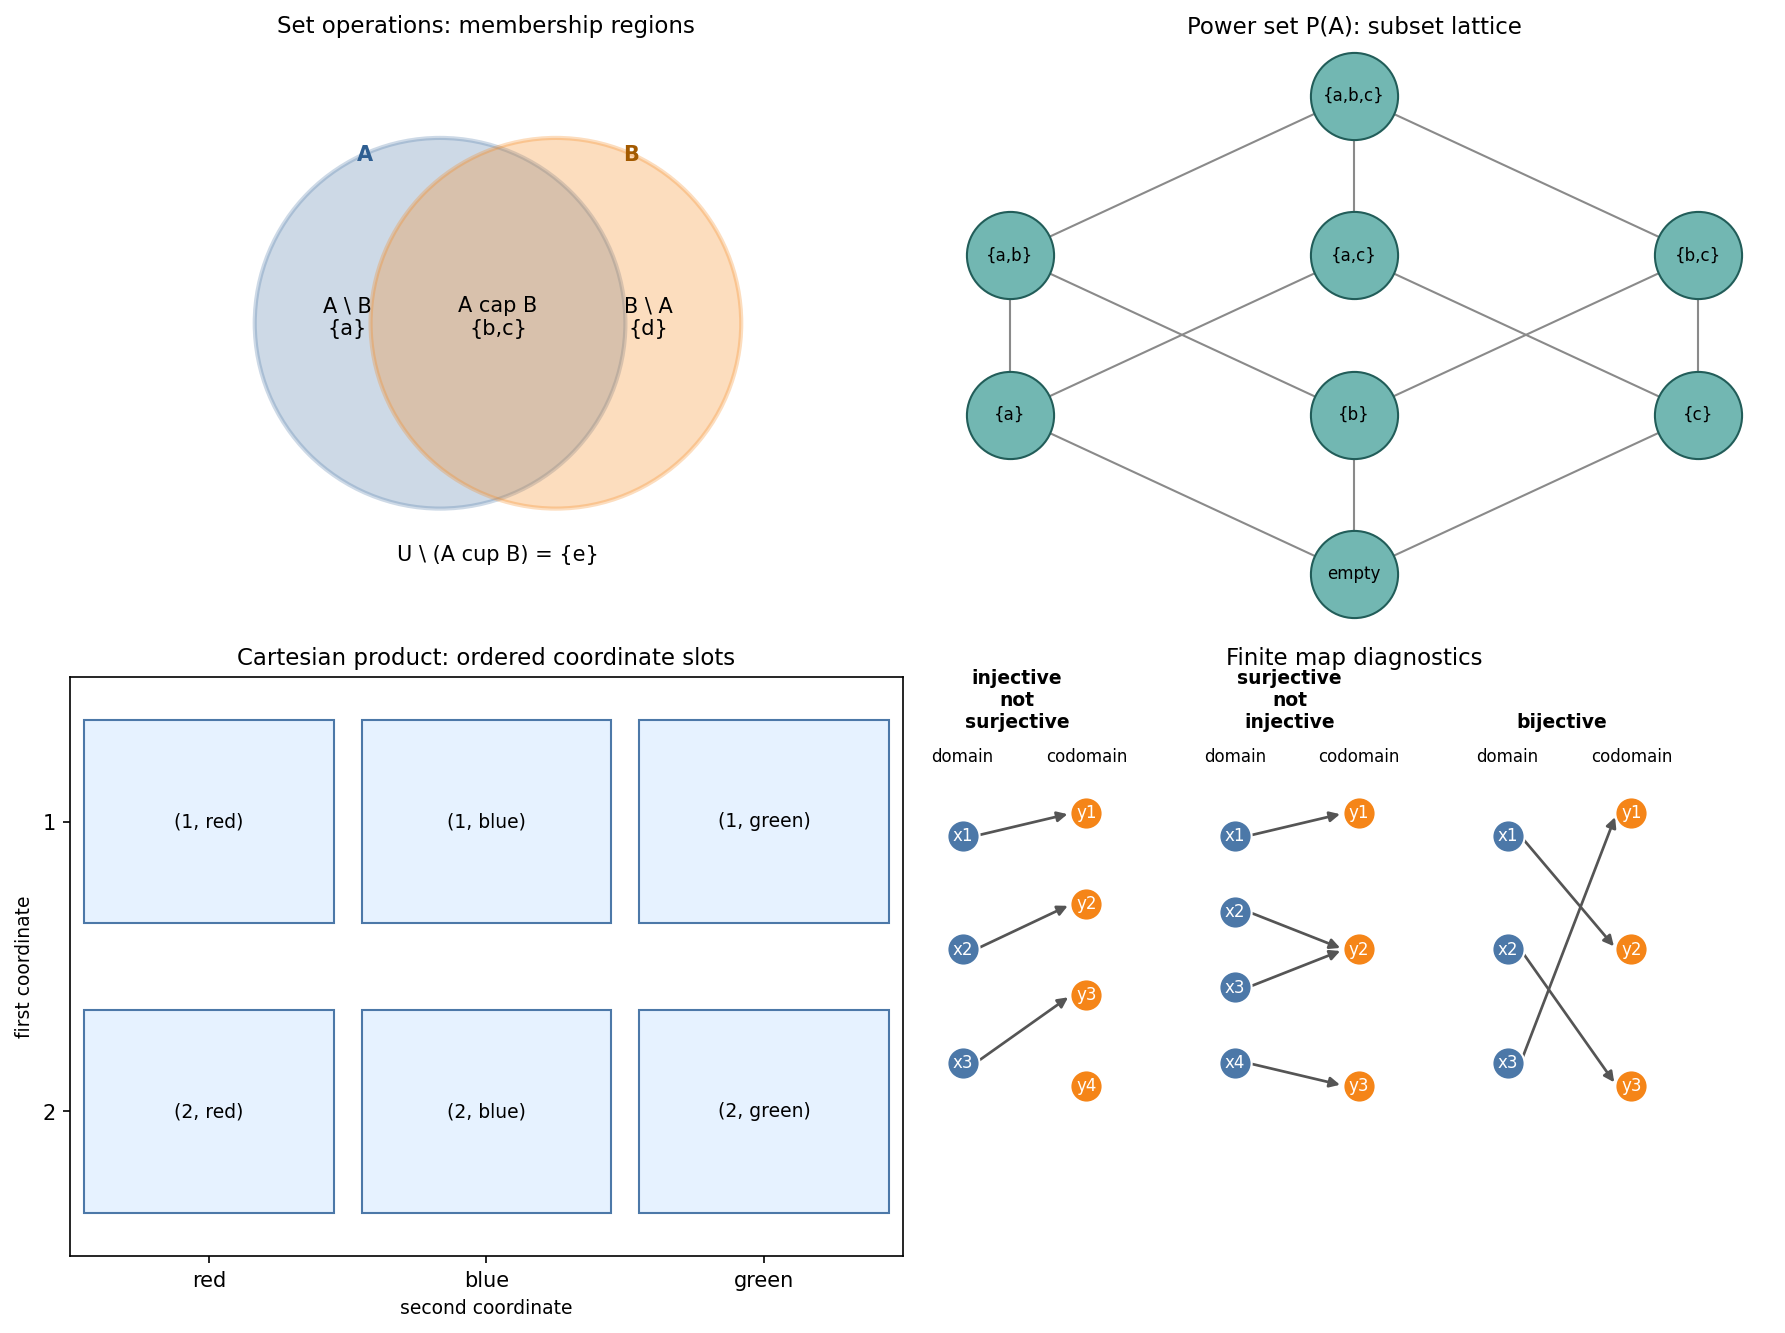

In [4]:
display_artifact(display_path(ARTIFACT_ROOT / "figures" / "set_power_cartesian_map_panel.png"), width=920)
display_artifact(display_path(ARTIFACT_ROOT / "tables" / "map_classification.csv"))


## 2. Finite Groups, Cayley Tables, Homomorphisms, and Cayley Graphs

A finite group can be audited like a small software interface. The operation must never leave the set. There must be a neutral element. Every element must have an inverse. Parentheses must not matter. Commutativity is optional, and seeing where it fails is often more informative than memorizing that it can fail.

The cyclic group `C4` models rotations of a square by quarter turns. The dihedral group `D3` models the rotations and reflections of a triangle. The `D3` Cayley graph uses two generators, a rotation `r` and a reflection `s`; following colored arrows composes transformations.


In [5]:
def check_finite_group(elements, op, identity):
    element_set = set(elements)
    closure = all(op(a, b) in element_set for a in elements for b in elements)
    identity_ok = all(op(identity, a) == a and op(a, identity) == a for a in elements)
    inverse_ok = all(any(op(a, b) == identity and op(b, a) == identity for b in elements) for a in elements)
    associativity = all(op(op(a, b), c) == op(a, op(b, c)) for a in elements for b in elements for c in elements)
    commutative = all(op(a, b) == op(b, a) for a in elements for b in elements)
    return {
        "closure": closure,
        "identity": identity_ok,
        "inverses": inverse_ok,
        "associativity": associativity,
        "commutative": commutative,
    }

C4 = list(range(4))
def c4_op(a, b):
    return (a + b) % 4

def c4_name(k):
    return f"r^{k}" if k else "e"

c4_table = pd.DataFrame(
    [[c4_name(c4_op(a, b)) for b in C4] for a in C4],
    index=[c4_name(a) for a in C4],
    columns=[c4_name(b) for b in C4],
)
c4_table.to_csv(ARTIFACT_ROOT / "tables" / "c4_cayley_table.csv")

# D3 elements are r^i s^j with i in {0,1,2}; multiplication uses s r s = r^{-1}.
D3 = [(i, j) for j in [0, 1] for i in range(3)]
def d3_op(a, b):
    i, j = a
    k, ell = b
    return ((i + ((-1) ** j) * k) % 3, (j + ell) % 2)

def d3_name(g):
    i, j = g
    if j == 0:
        return ["e", "r", "r^2"][i]
    return ["s", "rs", "r^2s"][i]

d3_table = pd.DataFrame(
    [[d3_name(d3_op(a, b)) for b in D3] for a in D3],
    index=[d3_name(a) for a in D3],
    columns=[d3_name(b) for b in D3],
)
d3_table.to_csv(ARTIFACT_ROOT / "tables" / "d3_cayley_table.csv")

c4_group_checks = check_finite_group(C4, c4_op, 0)
d3_group_checks = check_finite_group(D3, d3_op, (0, 0))
subgroup_C2 = [0, 2]
c2_closed_inside_c4 = all(c4_op(a, b) in subgroup_C2 for a in subgroup_C2 for b in subgroup_C2)

phi = {0: 0, 1: 1, 2: 2, 3: 3}
psi = {0: 0, 1: 1, 2: 0, 3: 1}
phi_hom = all(phi[c4_op(a, b)] == (phi[a] + phi[b]) % 4 for a in C4 for b in C4)
psi_hom = all(psi[c4_op(a, b)] == (psi[a] + psi[b]) % 2 for a in C4 for b in C4)
psi_injective = len(set(psi.values())) == len(C4)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), gridspec_kw={"width_ratios": [1, 1.15]})
ax = axes[0]
ax.set_title("C4 Cayley graph generated by r")
G_c4 = nx.DiGraph()
for a in C4:
    G_c4.add_edge(c4_name(a), c4_name(c4_op(a, 1)))
pos_c4 = nx.circular_layout(G_c4)
nx.draw_networkx_nodes(G_c4, pos_c4, ax=ax, node_color="#4C78A8", node_size=1500, edgecolors="white")
nx.draw_networkx_labels(G_c4, pos_c4, ax=ax, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G_c4, pos_c4, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=2, edge_color="#333333", connectionstyle="arc3,rad=0.16")
ax.text(0, -1.25, "Every arrow means compose with one 90 degree rotation.", ha="center", fontsize=9)
ax.set_axis_off()

ax = axes[1]
ax.set_title("C4 Cayley table: row composed with column")
ax.axis("off")
table = ax.table(cellText=c4_table.values, rowLabels=c4_table.index, colLabels=c4_table.columns, cellLoc="center", loc="center")
table.scale(1.2, 1.6)
for key, cell in table.get_celld().items():
    cell.set_edgecolor("#dddddd")
    if key[0] == 0 or key[1] == -1:
        cell.set_facecolor("#E6F2FF")
fig.tight_layout()
save_matplotlib(fig, "chapter-01", "c4_cayley_graph_and_table.png", root=BOOK_ROOT / "artifacts")
plt.close(fig)

G_d3 = nx.DiGraph()
for g in D3:
    for generator, label in [((1, 0), "r"), ((0, 1), "s")]:
        G_d3.add_edge(d3_name(g), d3_name(d3_op(g, generator)), generator=label)
pos_d3 = nx.circular_layout(G_d3)
edge_colors = ["#4C78A8" if G_d3.edges[e]["generator"] == "r" else "#F58518" for e in G_d3.edges]
fig, ax = plt.subplots(figsize=(7.2, 6.4))
ax.set_title("D3 Cayley graph: rotations and reflections of a triangle")
nx.draw_networkx_nodes(G_d3, pos_d3, ax=ax, node_size=1600, node_color="#72B7B2", edgecolors="#1f4f4b")
nx.draw_networkx_labels(G_d3, pos_d3, ax=ax, font_weight="bold")
nx.draw_networkx_edges(G_d3, pos_d3, ax=ax, arrows=True, arrowsize=16, edge_color=edge_colors, width=2, connectionstyle="arc3,rad=0.1")
ax.plot([], [], color="#4C78A8", lw=3, label="compose with r")
ax.plot([], [], color="#F58518", lw=3, label="compose with s")
ax.legend(loc="lower center", ncol=2, frameon=False)
ax.text(0, -1.28, "Non-commutativity appears because r then s lands differently from s then r.", ha="center", fontsize=9)
ax.set_axis_off()
fig.tight_layout()
save_matplotlib(fig, "chapter-01", "d3_noncommutative_cayley_graph.png", root=BOOK_ROOT / "artifacts")
plt.close(fig)

edge_traces = []
for gen_label, color in [("r", "#4C78A8"), ("s", "#F58518")]:
    xs, ys = [], []
    for u_node, v_node, data in G_d3.edges(data=True):
        if data["generator"] == gen_label:
            xs.extend([pos_d3[u_node][0], pos_d3[v_node][0], None])
            ys.extend([pos_d3[u_node][1], pos_d3[v_node][1], None])
    edge_traces.append(go.Scatter(x=xs, y=ys, mode="lines", line=dict(width=3, color=color), name=f"compose with {gen_label}"))
node_trace = go.Scatter(
    x=[pos_d3[n][0] for n in G_d3.nodes],
    y=[pos_d3[n][1] for n in G_d3.nodes],
    mode="markers+text",
    text=list(G_d3.nodes),
    textposition="middle center",
    marker=dict(size=42, color="#72B7B2", line=dict(width=2, color="#1f4f4b")),
    name="D3 elements",
)
fig_html = go.Figure(edge_traces + [node_trace])
fig_html.update_layout(
    title="D3 Cayley graph with rotation and reflection generators",
    showlegend=True,
    width=760,
    height=560,
    margin=dict(l=20, r=20, t=60, b=20),
    xaxis=dict(visible=False, scaleanchor="y"),
    yaxis=dict(visible=False),
    plot_bgcolor="white",
)
save_plotly_html(fig_html, "chapter-01", "d3_cayley_graph_generators.html", root=BOOK_ROOT / "artifacts")

checks.update({
    "c4_group_axioms": c4_group_checks,
    "d3_group_axioms": d3_group_checks,
    "c2_subgroup_of_c4_closed": c2_closed_inside_c4,
    "c4_to_z4_phi_homomorphism": phi_hom,
    "c4_to_c2_psi_homomorphism": psi_hom,
    "c4_to_c2_psi_injective": psi_injective,
    "d3_noncommutative_witness": {
        "r_then_s": d3_name(d3_op((1, 0), (0, 1))),
        "s_then_r": d3_name(d3_op((0, 1), (1, 0))),
    },
})
assert all(c4_group_checks.values())
assert all([d3_group_checks["closure"], d3_group_checks["identity"], d3_group_checks["inverses"], d3_group_checks["associativity"]])
assert d3_group_checks["commutative"] is False
assert phi_hom and psi_hom and not psi_injective
c4_table


,e,r^1,r^2,r^3
e,e,r^1,r^2,r^3
r^1,r^1,r^2,r^3,e
r^2,r^2,r^3,e,r^1
r^3,r^3,e,r^1,r^2


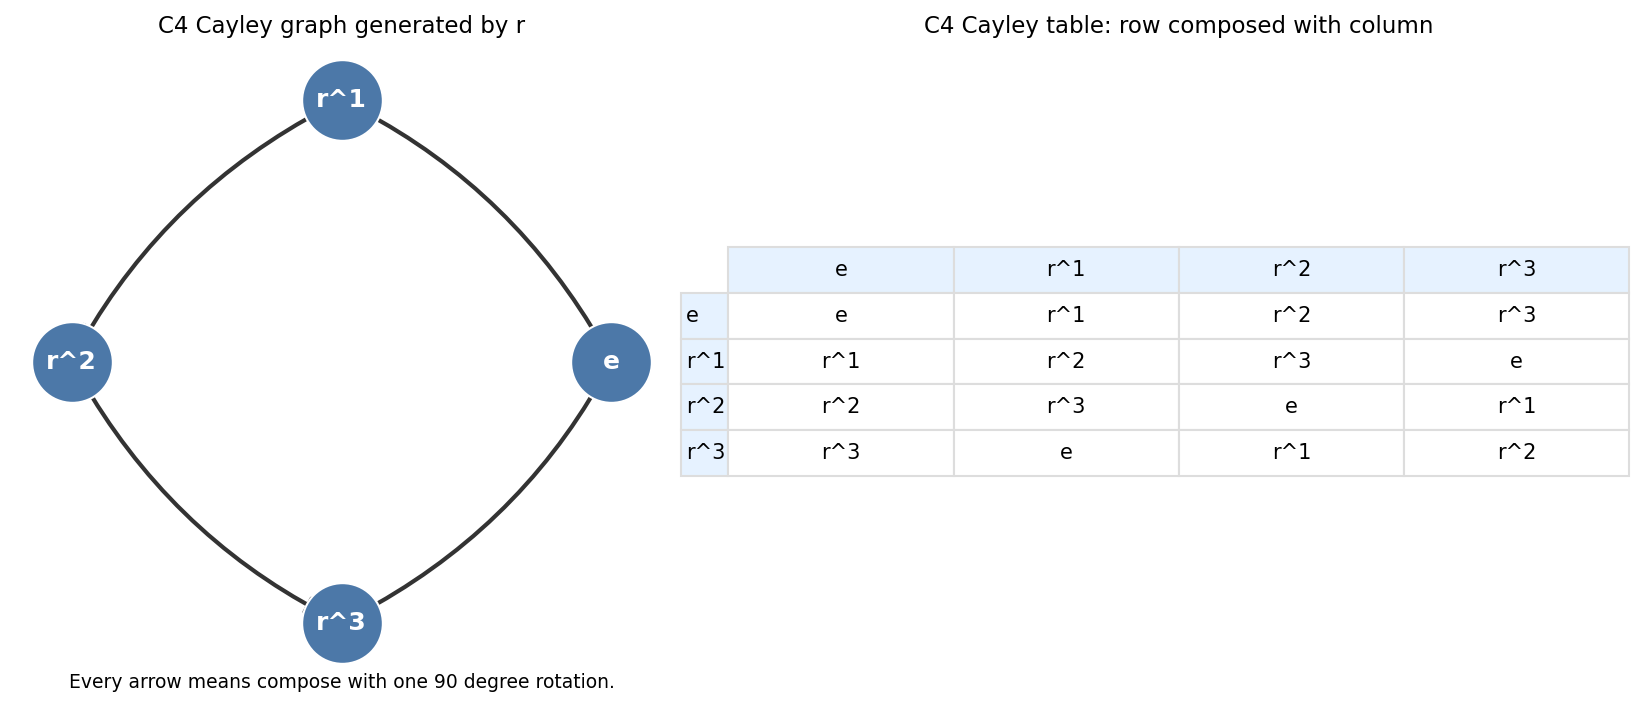

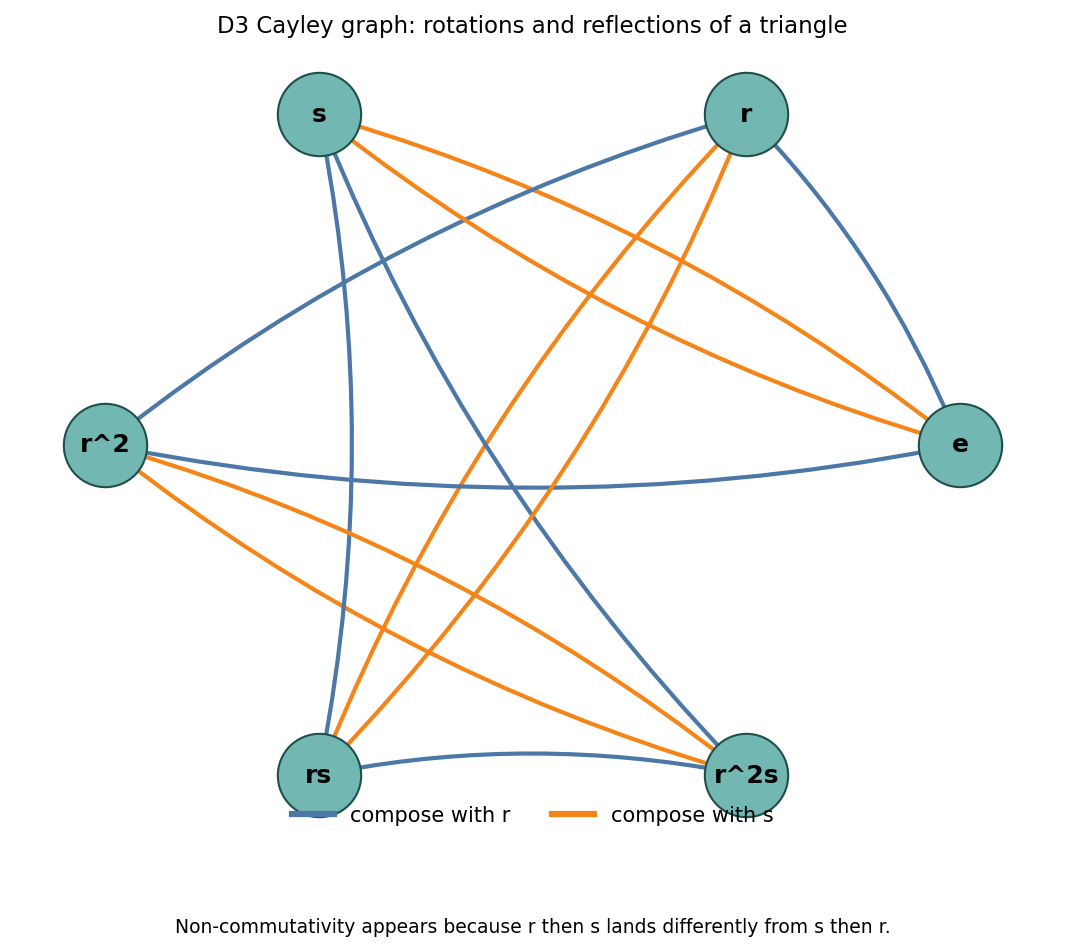

In [6]:
display_artifact(display_path(ARTIFACT_ROOT / "figures" / "c4_cayley_graph_and_table.png"), width=900)
display_artifact(display_path(ARTIFACT_ROOT / "figures" / "d3_noncommutative_cayley_graph.png"), width=720)
display_artifact(display_path(ARTIFACT_ROOT / "html" / "d3_cayley_graph_generators.html"), width="100%", height=600)
display_artifact(display_path(ARTIFACT_ROOT / "tables" / "d3_cayley_table.csv"))


## 3. Group Actions, Orbits, Invariance, and Equivariance

A group action connects the abstract operation table to data. For `C4`, the same group can rotate square vertices, rotate a four-pixel signal on those vertices, or rotate a small image. The action axioms say two things: the identity transformation changes nothing, and composing transformations before acting is equivalent to acting twice.

An invariant function collapses every element of an orbit to the same value. An equivariant function does not collapse the orbit; it keeps track of the transformation in a predictable way. The finite experiment below uses orbit pooling for invariance and circular convolution for equivariance.


In [7]:
def vertex_action(g, x):
    return (x + g) % 4

identity_action_ok = all(vertex_action(0, x) == x for x in C4)
compatibility_action_ok = all(vertex_action(c4_op(g, h), x) == vertex_action(g, vertex_action(h, x)) for g in C4 for h in C4 for x in C4)
orbit_of_zero = sorted({vertex_action(g, 0) for g in C4})

signal = np.array([0.2, 1.0, -0.4, 0.7])
kernel = np.array([0.55, -0.2, 0.35, 0.1])

def rotate_signal(x, g):
    return np.roll(x, g)

def orbit_pool(x):
    return float(np.mean([rotate_signal(x, g).sum() for g in C4]))

def circular_convolution(x, h):
    return np.array([sum(h[j] * x[(i - j) % len(x)] for j in range(len(x))) for i in range(len(x))])

base_invariant = orbit_pool(signal)
base_equivariant = circular_convolution(signal, kernel)
invariant_residuals = []
equivariant_residuals = []
for g in C4:
    invariant_residuals.append(abs(orbit_pool(rotate_signal(signal, g)) - base_invariant))
    equivariant_residuals.append(float(np.max(np.abs(circular_convolution(rotate_signal(signal, g), kernel) - rotate_signal(base_equivariant, g)))))

image = np.zeros((6, 6))
image[1:5, 1] = 1
image[4, 1:5] = 1
image[2, 2] = 0.65
image_orbit = [np.rot90(image, k=-g) for g in C4]
image_intensities = [float(img.sum()) for img in image_orbit]

fig, axes = plt.subplots(2, 4, figsize=(12, 6.5))
for g, ax in enumerate(axes[0]):
    ax.imshow(image_orbit[g], cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"image acted on by r^{g}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.5, -0.16, f"sum = {image_intensities[g]:.2f}", transform=ax.transAxes, ha="center", fontsize=9)

for g, ax in enumerate(axes[1]):
    rotated = rotate_signal(signal, g)
    equiv = circular_convolution(rotated, kernel)
    expected = rotate_signal(base_equivariant, g)
    xs = np.arange(4)
    ax.bar(xs - 0.18, equiv, width=0.36, color="#4C78A8", label="conv(r^g x)" if g == 0 else None)
    ax.bar(xs + 0.18, expected, width=0.36, color="#F58518", alpha=0.75, label="r^g conv(x)" if g == 0 else None)
    ax.set_title(f"equivariance test r^{g}")
    ax.set_xticks(xs, ["A", "B", "C", "D"])
    ax.axhline(0, color="#333333", lw=0.8)
    ax.text(0.5, -0.28, f"max residual {equivariant_residuals[g]:.1e}", transform=ax.transAxes, ha="center", fontsize=8)
axes[1, 0].legend(loc="upper left", fontsize=8, frameon=False)
fig.suptitle("C4 action: orbit invariance and equivariant circular convolution", y=1.02)
fig.tight_layout()
save_matplotlib(fig, "chapter-01", "action_orbit_invariance_equivariance.png", root=BOOK_ROOT / "artifacts")
plt.close(fig)

checks.update({
    "c4_action_identity": identity_action_ok,
    "c4_action_compatibility": compatibility_action_ok,
    "orbit_of_vertex_zero": orbit_of_zero,
    "image_orbit_intensity_range": float(max(image_intensities) - min(image_intensities)),
    "max_invariant_pooling_residual": float(max(invariant_residuals)),
    "max_equivariance_residual": float(max(equivariant_residuals)),
})
assert identity_action_ok and compatibility_action_ok
assert orbit_of_zero == C4
assert max(invariant_residuals) < 1e-12
assert max(equivariant_residuals) < 1e-12
pd.DataFrame({"rotation": [c4_name(g) for g in C4], "invariant_residual": invariant_residuals, "equivariant_residual": equivariant_residuals})


,rotation,invariant_residual,equivariant_residual
0,e,0.0,0.0
1,r^1,0.0,0.0
2,r^2,0.0,0.0
3,r^3,0.0,0.0


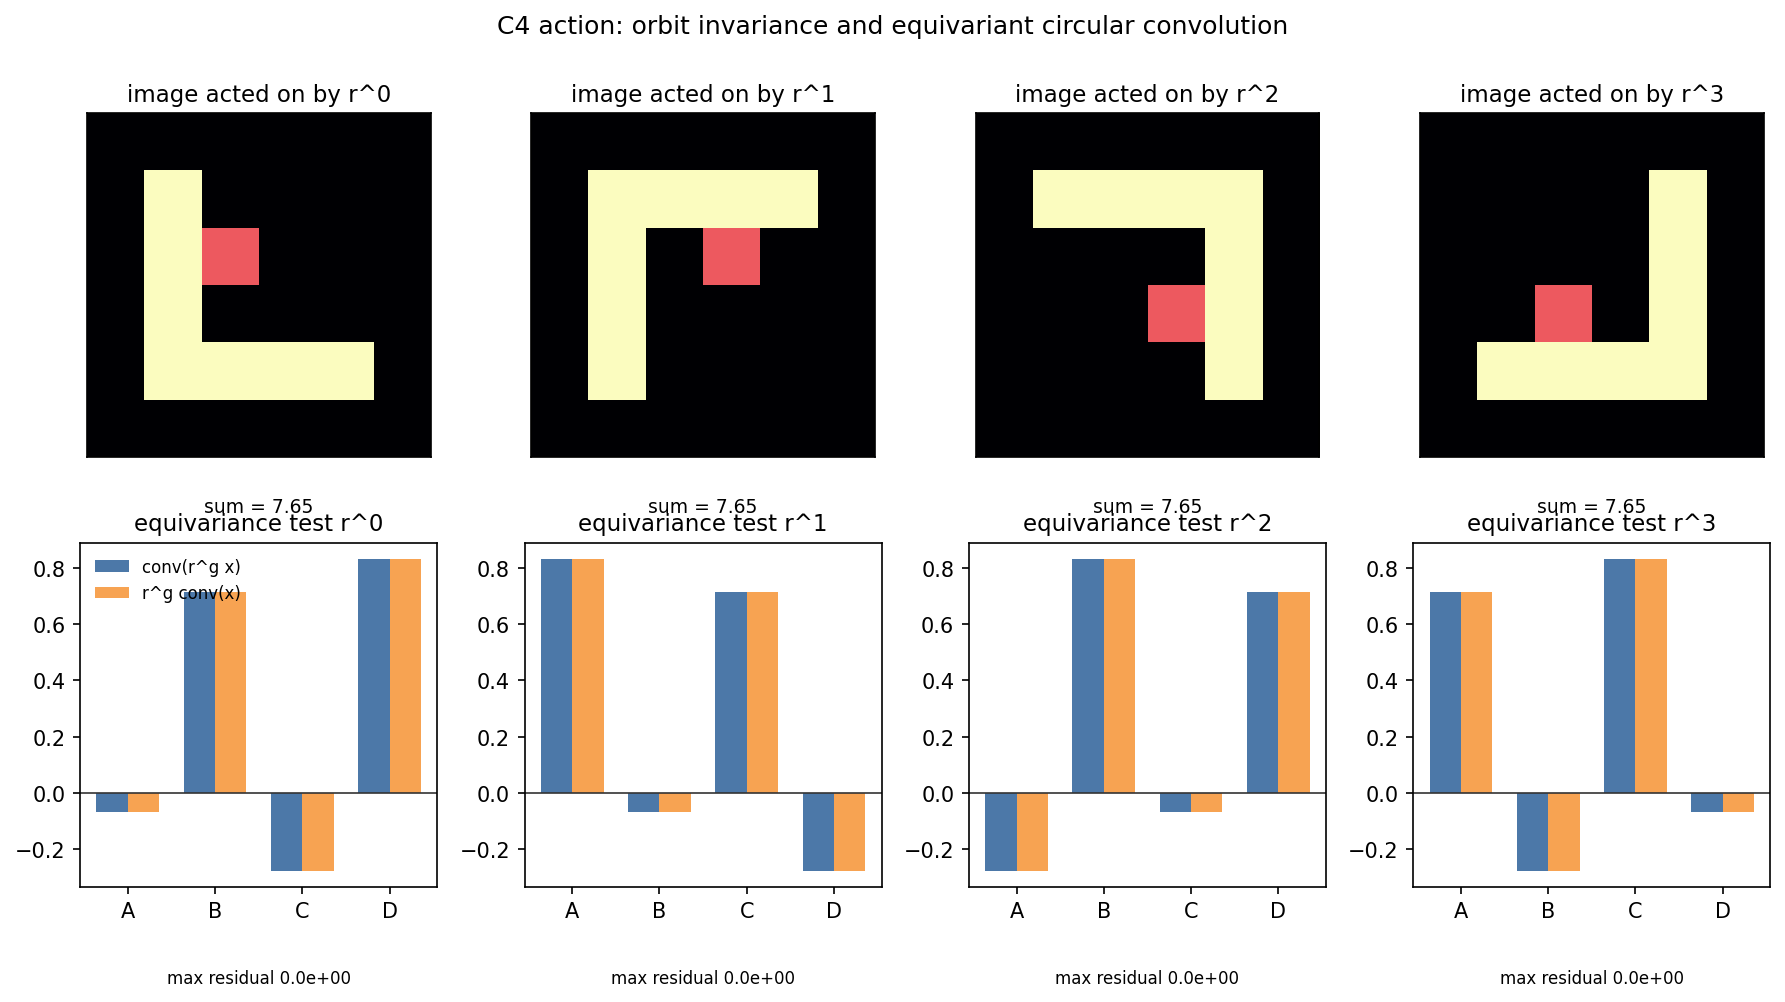

In [8]:
display_artifact(display_path(ARTIFACT_ROOT / "figures" / "action_orbit_invariance_equivariance.png"), width=940)


## 4. Tensor Spaces and Einstein Summation Checks

The chapter moves from vector spaces to tensor spaces because deep-learning data rarely arrives as a single vector. Images are often shaped like `[batch, channel, height, width]`; graph signals can carry node, feature, and layer axes; attention scores carry batch, query, and key axes.

Einstein notation is useful because it exposes which indices survive and which indices are summed out. In code, `np.einsum` makes that notation executable. The checks below compare `einsum` expressions with explicit NumPy operations so the index notation is not trusted blindly.


In [9]:
u = rng.normal(size=3)
v = rng.normal(size=3)
w = rng.normal(size=3)
alpha = 1.7
beta = -0.4
vector_space_residuals = {
    "addition_associativity": float(np.max(np.abs((u + v) + w - (u + (v + w))))),
    "addition_commutativity": float(np.max(np.abs((u + v) - (v + u)))),
    "scalar_distributes_over_vector_addition": float(np.max(np.abs(alpha * (u + v) - (alpha * u + alpha * v)))),
    "scalar_distributes_over_scalar_addition": float(np.max(np.abs((alpha + beta) * u - (alpha * u + beta * u)))),
}

a, b, x1, x2, y1, y2 = sp.symbols("a b x1 x2 y1 y2")
x = sp.Matrix([x1, x2])
y = sp.Matrix([y1, y2])
symbolic_distributivity = sp.simplify(a * (x + y) - (a * x + a * y)) == sp.Matrix([0, 0])

vec_left = rng.normal(size=4)
vec_right = rng.normal(size=4)
M = rng.normal(size=(3, 4))
T = np.arange(2 * 3 * 4, dtype=float).reshape(2, 3, 4) / 10.0
contractor = rng.normal(size=3)
Q = rng.normal(size=(2, 3, 5))
K = rng.normal(size=(2, 4, 5))

dot_einsum = np.einsum("i,i->", vec_left, vec_right)
dot_direct = float(vec_left @ vec_right)
matvec_einsum = np.einsum("ij,j->i", M, vec_right)
matvec_direct = M @ vec_right
tensor_contract_einsum = np.einsum("ijk,j->ik", T, contractor)
tensor_contract_direct = np.tensordot(T, contractor, axes=([1], [0]))
attention_scores = np.einsum("bnd,bmd->bnm", Q, K)
attention_direct = np.stack([Q[b_idx] @ K[b_idx].T for b_idx in range(Q.shape[0])])

einsum_residuals = {
    "dot": float(abs(dot_einsum - dot_direct)),
    "matvec": float(np.max(np.abs(matvec_einsum - matvec_direct))),
    "rank3_contract": float(np.max(np.abs(tensor_contract_einsum - tensor_contract_direct))),
    "batched_attention_scores": float(np.max(np.abs(attention_scores - attention_direct))),
}

fig, ax = plt.subplots(figsize=(12, 6.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")
ax.set_title("Einstein summation: repeated indices are contracted", pad=16)

ax.text(0.3, 6.2, "Dot product", weight="bold")
ax.text(0.3, 5.75, "u_i v_i -> scalar", fontsize=10)
for i, color in enumerate(["#4C78A8", "#F58518", "#54A24B", "#B279A2"]):
    ax.add_patch(Rectangle((2.1 + i * 0.45, 5.55), 0.35, 0.35, facecolor=color, alpha=0.75))
    ax.add_patch(Rectangle((4.1 + i * 0.45, 5.55), 0.35, 0.35, facecolor=color, alpha=0.45))
ax.add_patch(FancyArrowPatch((6.2, 5.73), (7.1, 5.73), arrowstyle="-|>", mutation_scale=14, lw=1.6))
ax.add_patch(Circle((7.55, 5.73), 0.24, facecolor="#333333"))
ax.text(7.55, 5.73, "a", color="white", ha="center", va="center")

ax.text(0.3, 4.45, "Matrix-vector", weight="bold")
ax.text(0.3, 4.0, "M_ij v_j -> u_i", fontsize=10)
for row in range(3):
    for col in range(4):
        ax.add_patch(Rectangle((2.1 + col * 0.36, 3.55 - row * 0.36), 0.3, 0.3, facecolor="#72B7B2", alpha=0.35 + 0.12 * row))
for col in range(4):
    ax.add_patch(Rectangle((4.05 + col * 0.12, 3.55 - col * 0.02), 0.09, 0.9, facecolor="#F58518", alpha=0.65))
ax.add_patch(FancyArrowPatch((5.05, 3.2), (6.0, 3.2), arrowstyle="-|>", mutation_scale=14, lw=1.6))
for row in range(3):
    ax.add_patch(Rectangle((6.35, 3.55 - row * 0.36), 0.32, 0.3, facecolor="#4C78A8", alpha=0.7))
ax.text(6.85, 3.2, "index i remains", va="center", fontsize=9)

ax.text(0.3, 2.35, "Rank-3 contraction", weight="bold")
ax.text(0.3, 1.9, "T_ijk v_j -> M_ik", fontsize=10)
for layer in range(3):
    offset = layer * 0.18
    ax.add_patch(Rectangle((2.1 + offset, 1.35 + offset), 1.1, 0.8, facecolor="#B279A2", alpha=0.2 + 0.14 * layer, edgecolor="#7b4d73"))
ax.text(3.5, 1.75, "contract j", ha="center", va="center", fontsize=9)
ax.add_patch(FancyArrowPatch((4.15, 1.75), (5.15, 1.75), arrowstyle="-|>", mutation_scale=14, lw=1.6))
for row in range(2):
    for col in range(4):
        ax.add_patch(Rectangle((5.55 + col * 0.36, 1.95 - row * 0.36), 0.3, 0.3, facecolor="#4C78A8", alpha=0.7))
ax.text(7.2, 1.75, "indices i,k remain", va="center", fontsize=9)

ax.add_patch(Rectangle((8.55, 1.0), 2.7, 4.95, facecolor="#F7F7F7", edgecolor="#CCCCCC"))
ax.text(9.9, 5.55, "DL tensor axes", ha="center", weight="bold")
axis_rows = [("B", "batch"), ("C", "channel"), ("H", "height"), ("W", "width")]
for idx, (symbol, name) in enumerate(axis_rows):
    y0 = 4.85 - idx * 0.82
    ax.add_patch(Rectangle((8.95, y0 - 0.22), 0.48, 0.44, facecolor="#4C78A8", alpha=0.7))
    ax.text(9.19, y0, symbol, color="white", ha="center", va="center", weight="bold")
    ax.text(9.65, y0, name, va="center")
ax.text(9.9, 1.55, "einsum names axes\ninstead of hiding them", ha="center", fontsize=9)
fig.tight_layout()
save_matplotlib(fig, "chapter-01", "tensor_einsum_index_flow.png", root=BOOK_ROOT / "artifacts")
plt.close(fig)

checks.update({
    "vector_space_residuals": vector_space_residuals,
    "symbolic_distributivity_exact": bool(symbolic_distributivity),
    "einsum_residuals": einsum_residuals,
    "einsum_shapes": {
        "dot": [],
        "matvec": list(matvec_einsum.shape),
        "rank3_contract": list(tensor_contract_einsum.shape),
        "batched_attention_scores": list(attention_scores.shape),
    },
})
assert max(vector_space_residuals.values()) < 1e-12
assert symbolic_distributivity
assert max(einsum_residuals.values()) < 1e-12
pd.DataFrame([
    {"expression": "i,i->", "result_shape": "scalar", "max_residual": einsum_residuals["dot"]},
    {"expression": "ij,j->i", "result_shape": str(matvec_einsum.shape), "max_residual": einsum_residuals["matvec"]},
    {"expression": "ijk,j->ik", "result_shape": str(tensor_contract_einsum.shape), "max_residual": einsum_residuals["rank3_contract"]},
    {"expression": "bnd,bmd->bnm", "result_shape": str(attention_scores.shape), "max_residual": einsum_residuals["batched_attention_scores"]},
])


,expression,result_shape,max_residual
0,"i,i->",scalar,0.000000e+00
1,"ij,j->i","(3,)",0.000000e+00
2,"ijk,j->ik","(2, 4)",8.881784e-16
3,"bnd,bmd->bnm","(2, 3, 4)",8.881784e-16


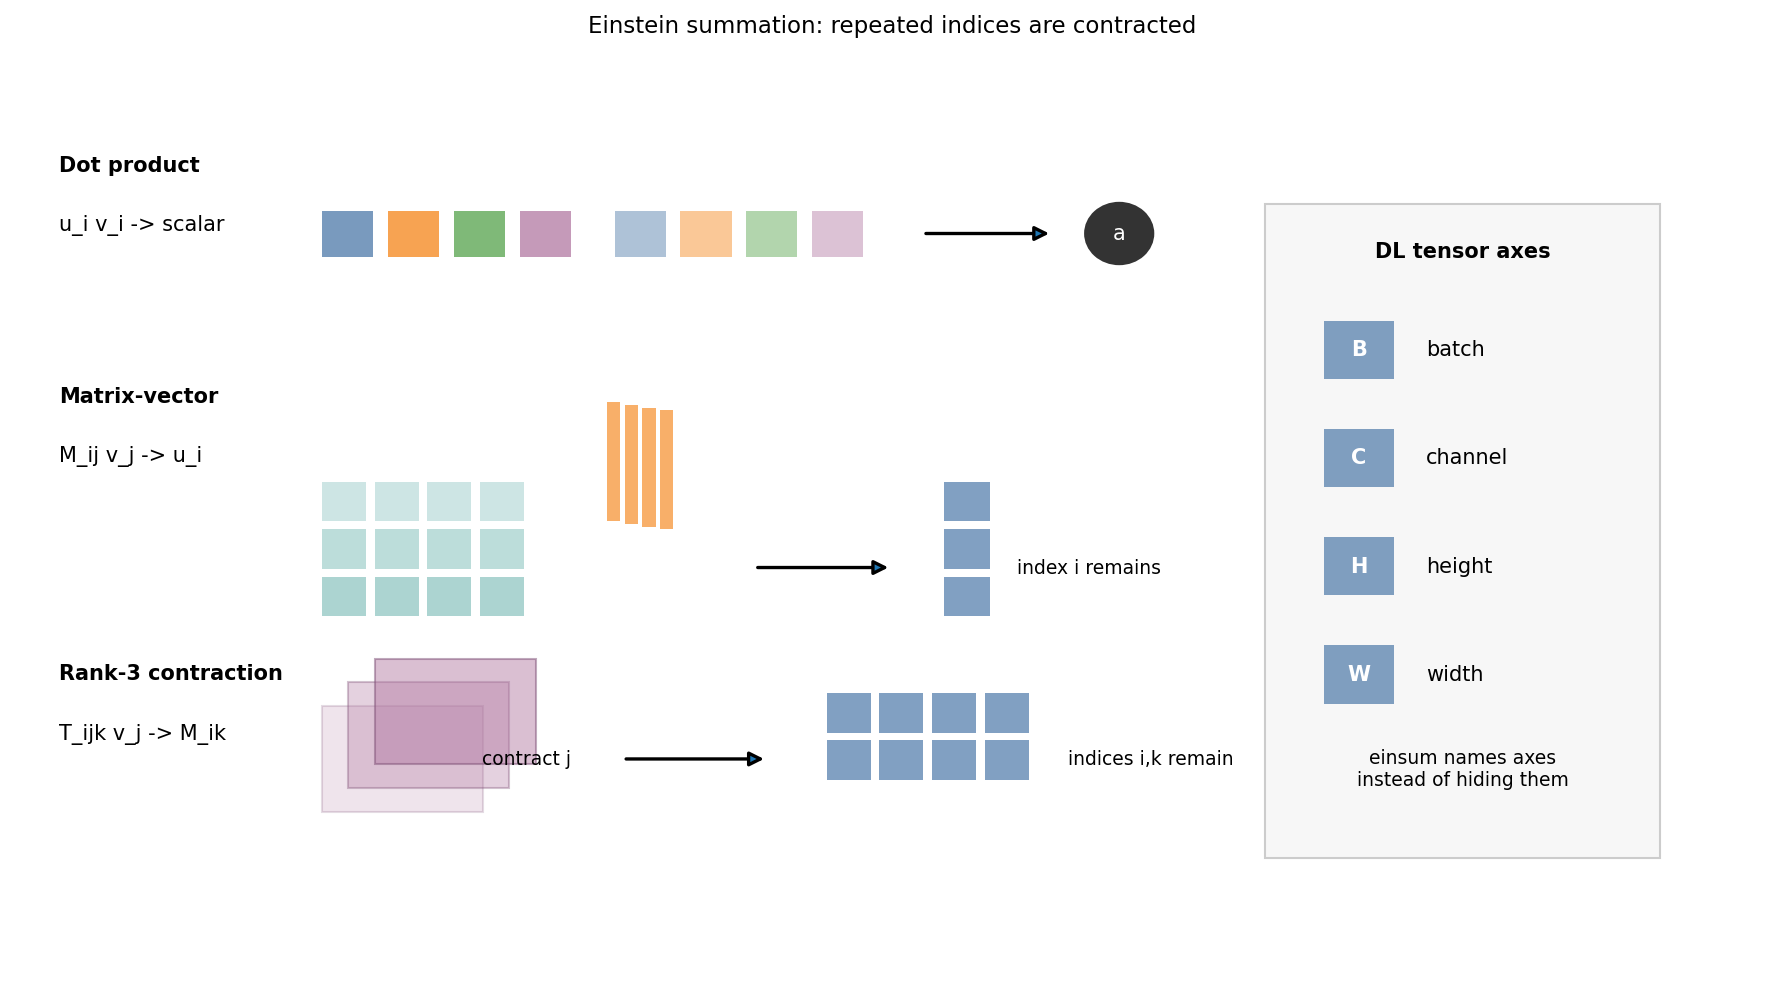

In [10]:
display_artifact(display_path(ARTIFACT_ROOT / "figures" / "tensor_einsum_index_flow.png"), width=920)


## 5. Applied lab: restricting a hypothesis class by symmetry

A model that must be invariant to `C4` should give the same scalar after rotating the input. A model that must be equivariant to `C4` should rotate its output by the same group element. The lab below is deliberately small: a four-location signal, a circular kernel, and four group elements. Change `lab_signal` or `lab_kernel` and rerun the cell; the residual columns should stay near zero because the construction, not the sampled values, enforces the symmetry.


In [11]:
lab_signal = np.array([1.2, -0.7, 0.4, 0.9])
lab_kernel = np.array([0.25, 0.5, -0.1, 0.2])
lab_base_scalar = orbit_pool(lab_signal)
lab_base_feature = circular_convolution(lab_signal, lab_kernel)
lab_rows = []
for g in C4:
    transformed = rotate_signal(lab_signal, g)
    invariant_value = orbit_pool(transformed)
    equivariant_feature = circular_convolution(transformed, lab_kernel)
    expected_feature = rotate_signal(lab_base_feature, g)
    lab_rows.append({
        "group_element": c4_name(g),
        "invariant_value": invariant_value,
        "invariant_residual": abs(invariant_value - lab_base_scalar),
        "equivariant_max_residual": float(np.max(np.abs(equivariant_feature - expected_feature))),
    })
lab_df = pd.DataFrame(lab_rows)
lab_df.to_csv(ARTIFACT_ROOT / "tables" / "c4_equivariance_lab.csv", index=False)
checks.update({
    "lab_invariant_max_residual": float(lab_df["invariant_residual"].max()),
    "lab_equivariant_max_residual": float(lab_df["equivariant_max_residual"].max()),
})
assert checks["lab_invariant_max_residual"] < 1e-12
assert checks["lab_equivariant_max_residual"] < 1e-12
lab_df


,group_element,invariant_value,invariant_residual,equivariant_max_residual
0,e,1.8,0.000000e+00,0.0
1,r^1,1.8,0.000000e+00,0.0
2,r^2,1.8,2.220446e-16,0.0
3,r^3,1.8,0.000000e+00,0.0


## Final Sanity checks and Takeaways

The final cell writes a machine-readable invariant summary and checks that every concept artifact exists and is nonempty. The algebraic checks are the point: each visual is paired with a small invariant that a reader can audit.

**Takeaways.** Sets define domains. Maps define movement between domains. Groups define composable transformations. Group actions let those transformations touch data. Invariant functions erase orbit position; equivariant functions preserve it in the output. Tensor notation then gives a compact language for the array operations used to implement these ideas in geometric deep learning.


In [12]:
artifact_paths = [ARTIFACT_ROOT / rel for rel in EXPECTED_ARTIFACTS]
checks["artifact_count"] = len(artifact_paths)
checks["all_core_identities_passed"] = all([
    checks["power_set_cardinality"] == checks["power_set_expected"],
    checks["cartesian_cardinality"] == checks["cartesian_expected"],
    all(checks["c4_group_axioms"].values()),
    all([checks["d3_group_axioms"][key] for key in ["closure", "identity", "inverses", "associativity"]]),
    checks["d3_group_axioms"]["commutative"] is False,
    checks["c4_action_identity"],
    checks["c4_action_compatibility"],
    checks["max_invariant_pooling_residual"] < 1e-12,
    checks["max_equivariance_residual"] < 1e-12,
    max(checks["vector_space_residuals"].values()) < 1e-12,
    max(checks["einsum_residuals"].values()) < 1e-12,
])

# Write once so both check files are present before artifact-size accounting.
for filename in ["algebraic_structure_invariants.json", "final-sanity.json"]:
    (ARTIFACT_ROOT / "checks" / filename).write_text(json.dumps(checks, indent=2, sort_keys=True), encoding="utf-8")

records = assert_chapter_artifacts(artifact_paths)
for rel in [p for p in EXPECTED_ARTIFACTS if p.startswith("figures/")]:
    assert_nonblank_image(ARTIFACT_ROOT / rel)
assert checks["all_core_identities_passed"]

checks["artifact_sizes"] = {rel: int((ARTIFACT_ROOT / rel).stat().st_size) for rel in EXPECTED_ARTIFACTS}
for filename in ["algebraic_structure_invariants.json", "final-sanity.json"]:
    (ARTIFACT_ROOT / "checks" / filename).write_text(json.dumps(checks, indent=2, sort_keys=True), encoding="utf-8")

display_records = []
for record in records:
    record = dict(record)
    raw_path = Path(record["path"])
    if not raw_path.is_absolute() and raw_path.parts and raw_path.parts[0] == "artifacts":
        record["path"] = raw_path.as_posix()
    else:
        record["path"] = raw_path.resolve().relative_to(BOOK_ROOT).as_posix()
    display_records.append(record)
summary = pd.DataFrame(display_records)
display(summary)
display_artifact(display_path(ARTIFACT_ROOT / "checks" / "final-sanity.json"))
print(f"Final sanity checks passed for {len(records)} artifacts.")


,path,bytes
0,artifacts/chapter-01/figures/set_power_cartesi...,182515
1,artifacts/chapter-01/figures/c4_cayley_graph_a...,64318
2,artifacts/chapter-01/figures/d3_noncommutative...,135631
3,artifacts/chapter-01/figures/action_orbit_inva...,49396
4,artifacts/chapter-01/figures/tensor_einsum_ind...,56312
5,artifacts/chapter-01/html/d3_cayley_graph_gene...,9489
6,artifacts/chapter-01/tables/map_classification...,165
7,artifacts/chapter-01/tables/c4_cayley_table.csv,90
8,artifacts/chapter-01/tables/d3_cayley_table.csv,152
9,artifacts/chapter-01/tables/c4_equivariance_la...,174


Final sanity checks passed for 12 artifacts.
